In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
train='/content/train (1).csv'
test='/content/test (1).csv'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Training

In [ ]:
df=pd.read_csv(train)
df=df.dropna()
df.drop(columns=['id'],inplace=True)
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [ ]:
def df_encode(df):
  df['study_method']=df['study_method'].map({'coaching':'coaching','online videos':'online_videos','self-study':'self_study','group study':'group_study','mixed':'mixed'})

  df['sleep_quality']=df['sleep_quality'].map({'poor':0,'average':1,'good':2})
  df['facility_rating']=df['facility_rating'].map({'low':0,'medium':1,'high':2})
  df['exam_difficulty']=df['exam_difficulty'].map({'easy':0,'moderate':1,'hard':2})

  df['internet_access']=df['internet_access'].map({'no':0,'yes':1})

  OneHotEncoding=['study_method']
  df = pd.get_dummies(df, columns=OneHotEncoding, drop_first=False)

  df.drop(columns=['age','gender','course','internet_access','exam_difficulty'],inplace=True)
  return df
df=df_encode(df)

In [ ]:
def df_feature(df):
  df['study_efficiency'] = df['study_hours'] / df['sleep_hours']
  df['effective_study'] = df['study_hours'] * (df['class_attendance']/100)
  df['sleep_score'] = df['sleep_quality'] * df['sleep_hours']
  df['facility_effect'] = df['facility_rating'] * df['study_hours']

  df['log_study_hours'] = np.log1p(df['study_hours'])

  # df["rest_quality"] = df["sleep_hours"] * df["facility_rating"]
  # Safety: handle division edge cases
  df.replace([np.inf, -np.inf], 0, inplace=True)
  df.fillna(0, inplace=True)
  return df
df=df_feature(df)

#### Plotting

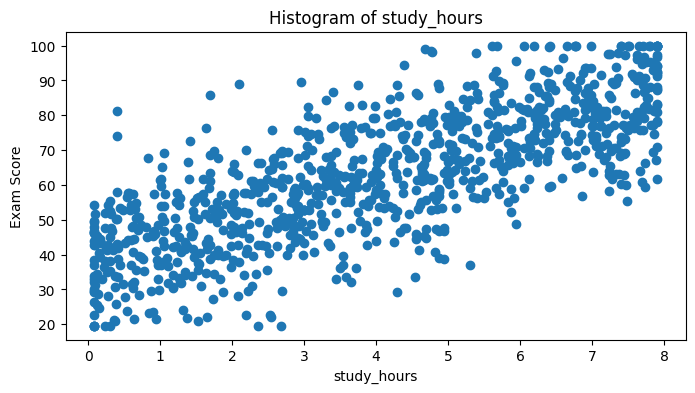

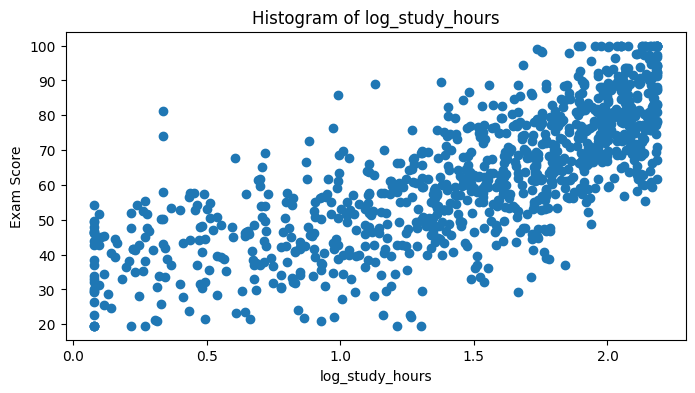

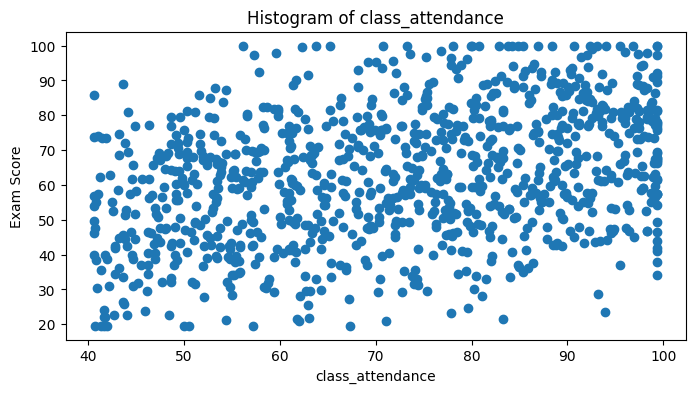

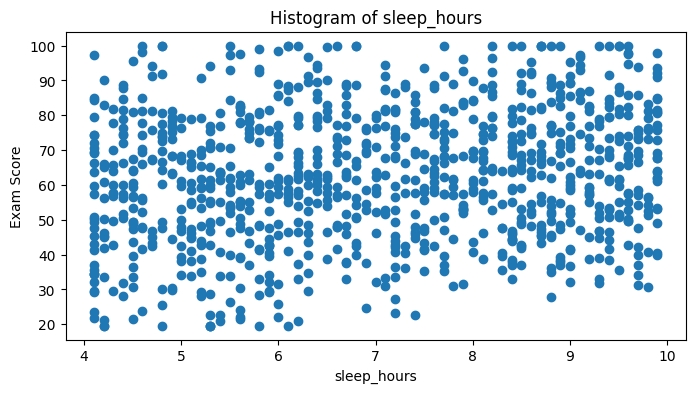

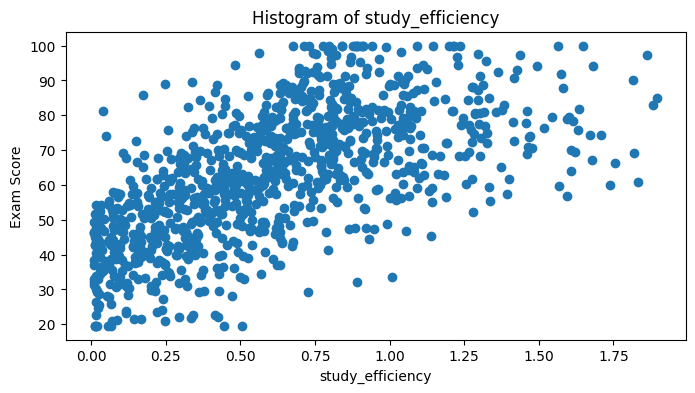

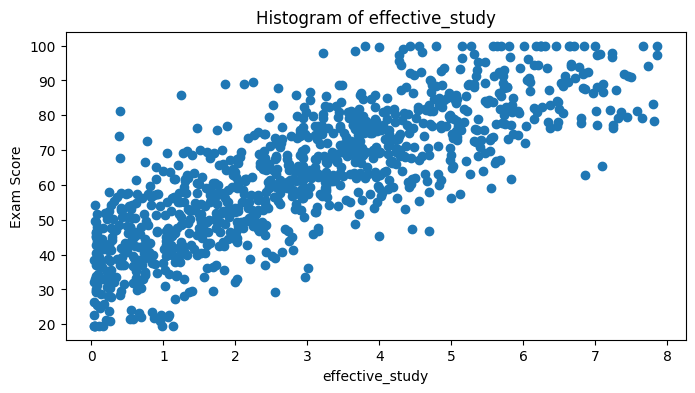

In [ ]:
col=['study_hours','log_study_hours','class_attendance','sleep_hours','study_efficiency','effective_study']
for c in col:
  plt.figure(figsize=(8,4))
  plt.scatter(df[c][:1000], df['exam_score'][:1000])
  plt.title(f'Histogram of {c}')
  plt.xlabel(c)
  plt.ylabel('Exam Score')
  plt.show()

#### Data Prepare

In [ ]:
X = df.drop(columns=['exam_score'])
y = df['exam_score']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
# mse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mse_lr = root_mean_squared_error(y_test, y_pred_lr)
print(f'Linear Regression RMSE: {mse_lr}')

Linear Regression RMSE: 8.887373786048077


In [ ]:
from lightgbm import LGBMRegressor

lgbm= LGBMRegressor(
    n_estimators = 1200,
    learning_rate = 0.05,
    max_depth = 6,
    min_child_samples = 50,
    subsample = 0.8,
    num_leaves = 63,
    colsample_bytree = 1.0,
    verbose = -1,
    random_state = 42,
    device = 'gpu',
    gpu_use_dp = False,
    )

lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
mse_lr = root_mean_squared_error(y_test, y_pred_lgbm)
print(f'LGBMRegressor RMSE: {mse_lr}')

LGBMRegressor RMSE: 8.741868119805616


In [ ]:
# from sklearn.model_selection import RandomizedSearchCV

# base_model = LGBMRegressor(
#     objective="regression",
#     metric="rmse",
#     device="gpu",
#     gpu_use_dp=False,          # faster GPU training
#     verbose=-1
# )
# param_dist = {
#     "n_estimators": [800, 1200, 1400],     # smaller first → faster convergence
#     "learning_rate": [0.03, 0.05],        # stable learning
#     "max_depth": [-1, 5, 7],
#     "num_leaves": [31, 63, 127],           # capacity control
#     "min_child_samples": [20, 40],
#     "subsample": [0.8, 1.0],               # regularization
#     "colsample_bytree": [0.8, 1.0],
# }
# rs = RandomizedSearchCV(
#     estimator=base_model,
#     param_distributions=param_dist,
#     n_iter=5,                 # better exploration
#     cv=3,
#     scoring="neg_root_mean_squared_error",
#     n_jobs=-1,
#     random_state=42,
#     verbose=1,
#     refit=True
# )
# rs.fit(X_train, y_train)

# best_model = rs.best_estimator_
# best_params = rs.best_params_
# best_score = -rs.best_score_

# best_model, best_params, best_score

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=50,
    subsample=0.8,
    colsample_bytree=1.0,
    tree_method='hist',
    predictor='gpu_predictor',
    random_state=42,
    verbosity=0
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
print(f'XGBRegressor RMSE: {rmse_xgb}')

XGBRegressor RMSE: 8.740753085780545


## Testing

In [ ]:
df_test=pd.read_csv(test)
df_test=df_test.dropna()
id=df_test['id']
df_test.drop(columns=['id'],inplace=True)
df_test=df_encode(df_test)
df_test=df_feature(df_test)
df_test.head()

,study_hours,class_attendance,sleep_hours,sleep_quality,facility_rating,study_method_coaching,study_method_group_study,study_method_mixed,study_method_online_videos,study_method_self_study,study_efficiency,effective_study,sleep_score,facility_effect,log_study_hours
0,6.85,65.2,5.2,0,2,False,True,False,False,False,1.317308,4.46620,0.0,13.70,2.060514
1,6.61,45.0,9.3,0,0,True,False,False,False,False,0.710753,2.97450,0.0,0.00,2.029463
2,6.60,98.5,6.2,2,1,False,True,False,False,False,1.064516,6.50100,12.4,6.60,2.028148
3,3.03,66.3,5.7,1,1,False,False,True,False,False,0.531579,2.00889,5.7,3.03,1.393766
4,2.03,42.4,9.2,1,0,True,False,False,False,False,0.220652,0.86072,9.2,0.00,1.108563


In [ ]:
prediction=lgbm.predict(df_test)

In [ ]:
submission = pd.DataFrame({
    "id": id,
    "exam_score": prediction
})
submission.to_csv("submission.csv", index=False)
print("submission.csv created successfully")

submission.csv created successfully


### using tf and keras

In [ ]:
import tensorflow as tf
from tensorflow import keras as k
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
k.utils.set_random_seed(42)

In [ ]:
# df.exam_score.value_counts(normalize=True, dropna=False, ascending=False)

In [ ]:
train_X=df.drop(['exam_score'], axis=1)
# train_X=df.drop(columns=['exam_score'])
train_y=df['exam_score']

In [ ]:
train_X=(train_X-train_X.mean())/train_X.std()

In [ ]:
X=train_X.to_numpy()
y=train_y.to_numpy()
X = X.astype(np.float32)
y = y.astype(np.float32)

In [ ]:
input_layer = k.Input(shape=(15,))

x = Dense(128, activation='relu')(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(32, activation='relu')(x)
output_layer = Dense(1, activation='linear')(x)

model = k.Model(inputs=input_layer, outputs=output_layer)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

In [ ]:
history=model.fit(X,
                  y,
                  epochs=15,
                  batch_size=256,
                  verbose=1,
                  validation_split=0.20)

Epoch 1/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 920.6432 - root_mean_squared_error: 27.9991 - val_loss: 80.1950 - val_root_mean_squared_error: 8.9552
Epoch 2/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 108.3539 - root_mean_squared_error: 10.4090 - val_loss: 79.6779 - val_root_mean_squared_error: 8.9262
Epoch 3/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 102.6099 - root_mean_squared_error: 10.1295 - val_loss: 79.6237 - val_root_mean_squared_error: 8.9232
Epoch 4/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 97.7084 - root_mean_squared_error: 9.8846 - val_loss: 80.2469 - val_root_mean_squared_error: 8.9581
Epoch 5/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 93.0205 - root_mean_squared_error: 9.6445 - val_loss: 79.2244 - val_root_mean_squared_error: 8.9008
Epoch 6/15
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 88.8412 - root_mean_squared_error: 9.4255 - val_loss: 80.3504 - val_root_mean_squared_error: 8.9638
Epoch 7/15
1969/1969 

In [ ]:
model.evaluate(X, y)

19688/19688 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - loss: 80.1133 - root_mean_squared_error: 8.9506


[80.08058166503906, 8.948775291442871]

In [ ]:
y_pred=model.predict(X)

from sklearn.metrics import root_mean_squared_error

rmse=root_mean_squared_error(y, y_pred)
print(rmse)

19688/19688 ━━━━━━━━━━━━━━━━━━━━ 28s 1ms/step
8.948769569396973


In [ ]:
# {model.fit}.history
# history.history

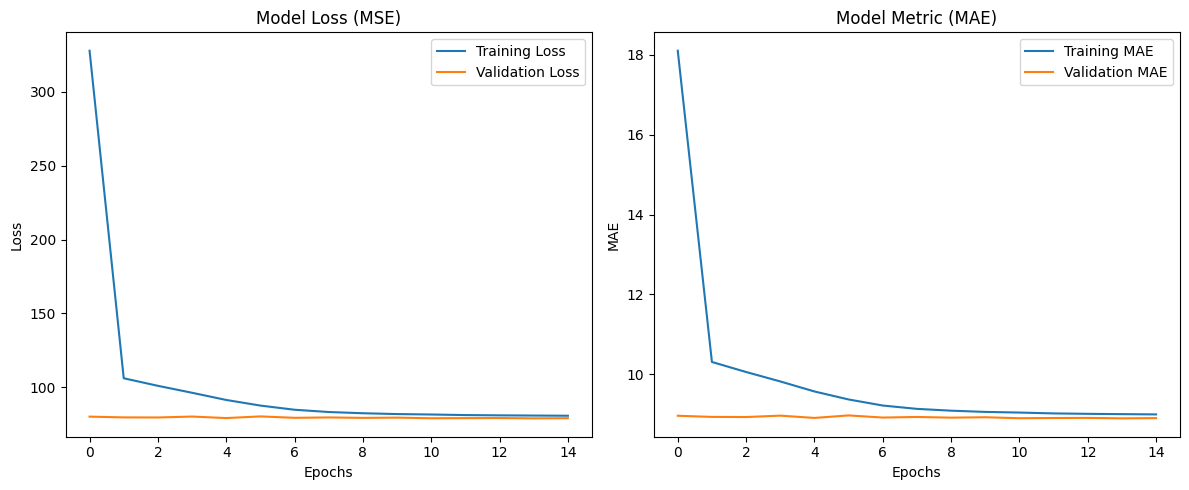

In [ ]:
def plot_history(history):
    # Plot Loss (MSE)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Metric (MAE)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['root_mean_squared_error'], label='Training MAE')
    plt.plot(history.history['val_root_mean_squared_error'], label='Validation MAE')
    plt.title('Model Metric (MAE)')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [ ]:
test_df=(test_df-test_df.mean())/test_df.std()
x_test=test_df.to_numpy()

In [ ]:
prediction=model.predict(x_test, batch_size=256)

1055/1055 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [ ]:
prediction=prediction.reshape(-1)
prediction

array([71.150894, 70.87185 , 88.89613 , ..., 88.21294 , 56.28272 ,
       70.1789  ], dtype=float32)

In [ ]:
submission = pd.DataFrame({
    "id": id,
    "exam_score": prediction
})
submission.to_csv("submission.csv", index=False)
print("\nsubmission.csv created successfully")


submission.csv created successfully
